Original class distribution: Counter({0: 432808, 1: 37645})
Class distribution after SMOTE: Counter({0: 302966, 1: 302966})


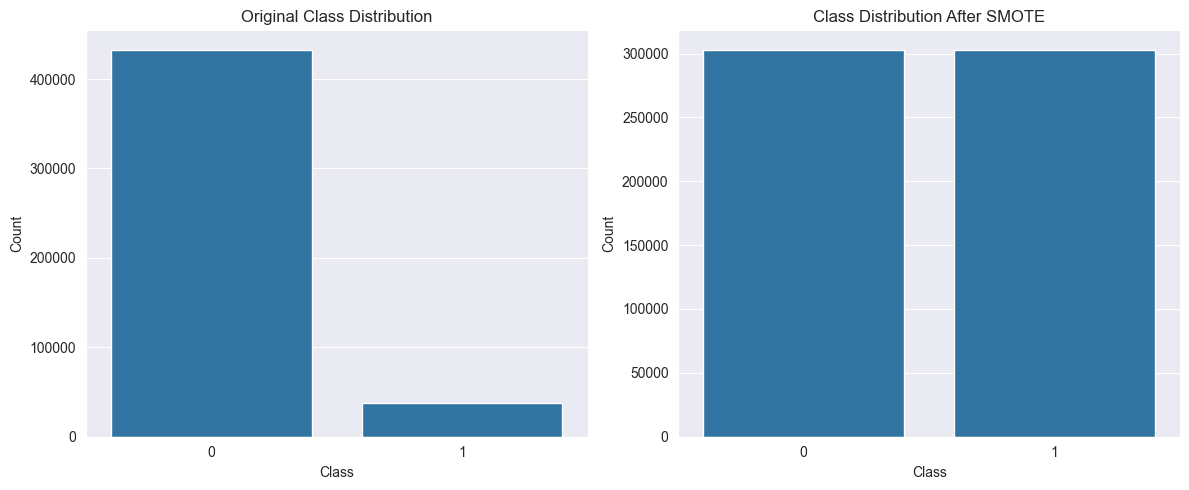


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98    129842
           1       0.84      0.81      0.82     11294

    accuracy                           0.97    141136
   macro avg       0.91      0.90      0.90    141136
weighted avg       0.97      0.97      0.97    141136



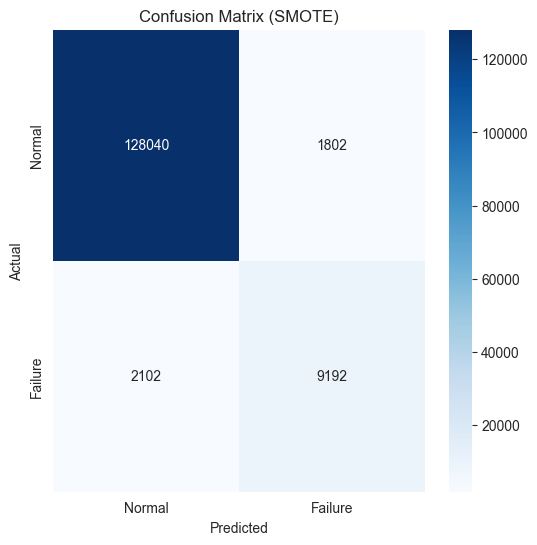


Classification Report (Without SMOTE):
              precision    recall  f1-score   support

           0       0.95      1.00      0.98    129842
           1       0.98      0.44      0.61     11294

    accuracy                           0.95    141136
   macro avg       0.97      0.72      0.79    141136
weighted avg       0.96      0.95      0.95    141136



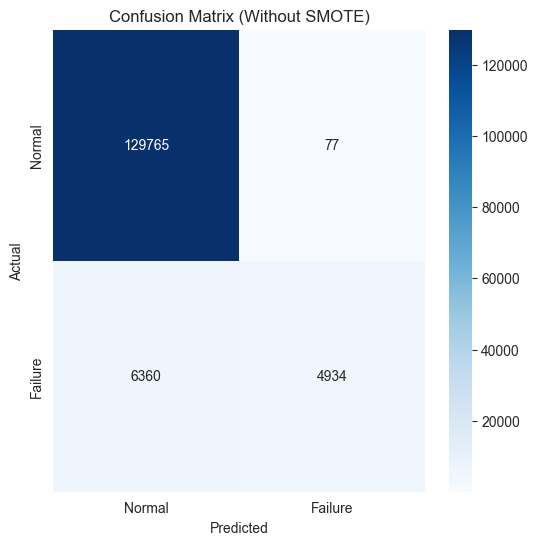

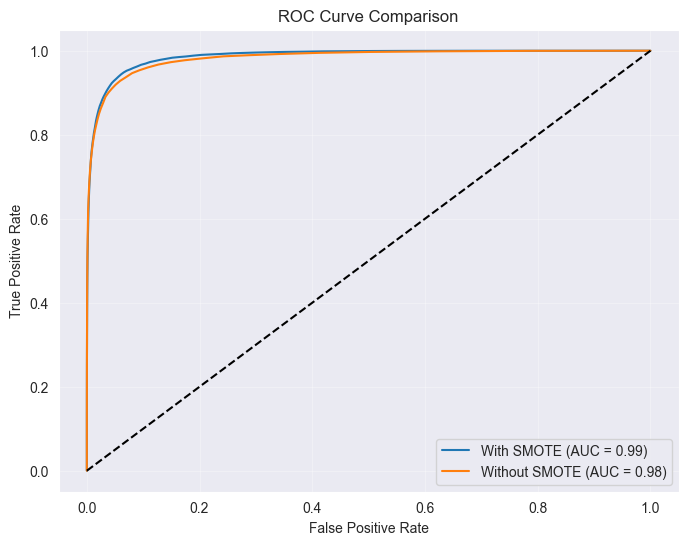

In [5]:
# Import additional packages for SMOTE
from imblearn.over_sampling import SMOTE
from collections import Counter

# Classification with SMOTE for Imbalance Handling
# First create binary failure indicator
data_cleaned['failure'] = (data_cleaned['errorcode'] != 0).astype(int)

# Prepare features and target for classification
X_class = data_cleaned[selected_features]
y_class = data_cleaned['failure']

# Check original class distribution
print("Original class distribution:", Counter(y_class))

# Split data
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class, y_class, test_size=0.3, random_state=42, stratify=y_class)

# Apply SMOTE only to the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_class, y_train_class)

# Check new class distribution after SMOTE
print("Class distribution after SMOTE:", Counter(y_train_smote))

# Visualize class distribution before and after SMOTE
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x=y_class)
plt.title('Original Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x=y_train_smote)
plt.title('Class Distribution After SMOTE')
plt.xlabel('Class')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Train a classifier with SMOTE data
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train_smote, y_train_smote)

# Evaluate on original test data (not SMOTE)
y_pred_class = rf_classifier.predict(X_test_class)

print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_class))

# Plot confusion matrix
cm = confusion_matrix(y_test_class, y_pred_class)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Failure'],
            yticklabels=['Normal', 'Failure'])
plt.title('Confusion Matrix (SMOTE)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Compare with model trained without SMOTE
rf_classifier_nosmote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier_nosmote.fit(X_train_class, y_train_class)
y_pred_nosmote = rf_classifier_nosmote.predict(X_test_class)

print("\nClassification Report (Without SMOTE):")
print(classification_report(y_test_class, y_pred_nosmote))

# Plot confusion matrix without SMOTE
cm_nosmote = confusion_matrix(y_test_class, y_pred_nosmote)
plt.figure(figsize=(6, 6))
sns.heatmap(cm_nosmote, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Failure'],
            yticklabels=['Normal', 'Failure'])
plt.title('Confusion Matrix (Without SMOTE)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Plot ROC curves for both models
plt.figure(figsize=(8, 6))

# With SMOTE
y_prob_smote = rf_classifier.predict_proba(X_test_class)[:, 1]
fpr_smote, tpr_smote, _ = roc_curve(y_test_class, y_prob_smote)
roc_auc_smote = auc(fpr_smote, tpr_smote)
plt.plot(fpr_smote, tpr_smote, label=f'With SMOTE (AUC = {roc_auc_smote:.2f})')

# Without SMOTE
y_prob_nosmote = rf_classifier_nosmote.predict_proba(X_test_class)[:, 1]
fpr_nosmote, tpr_nosmote, _ = roc_curve(y_test_class, y_prob_nosmote)
roc_auc_nosmote = auc(fpr_nosmote, tpr_nosmote)
plt.plot(fpr_nosmote, tpr_nosmote, label=f'Without SMOTE (AUC = {roc_auc_nosmote:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## Plot actual vs predicted failures over time for each turbine with SMOTE

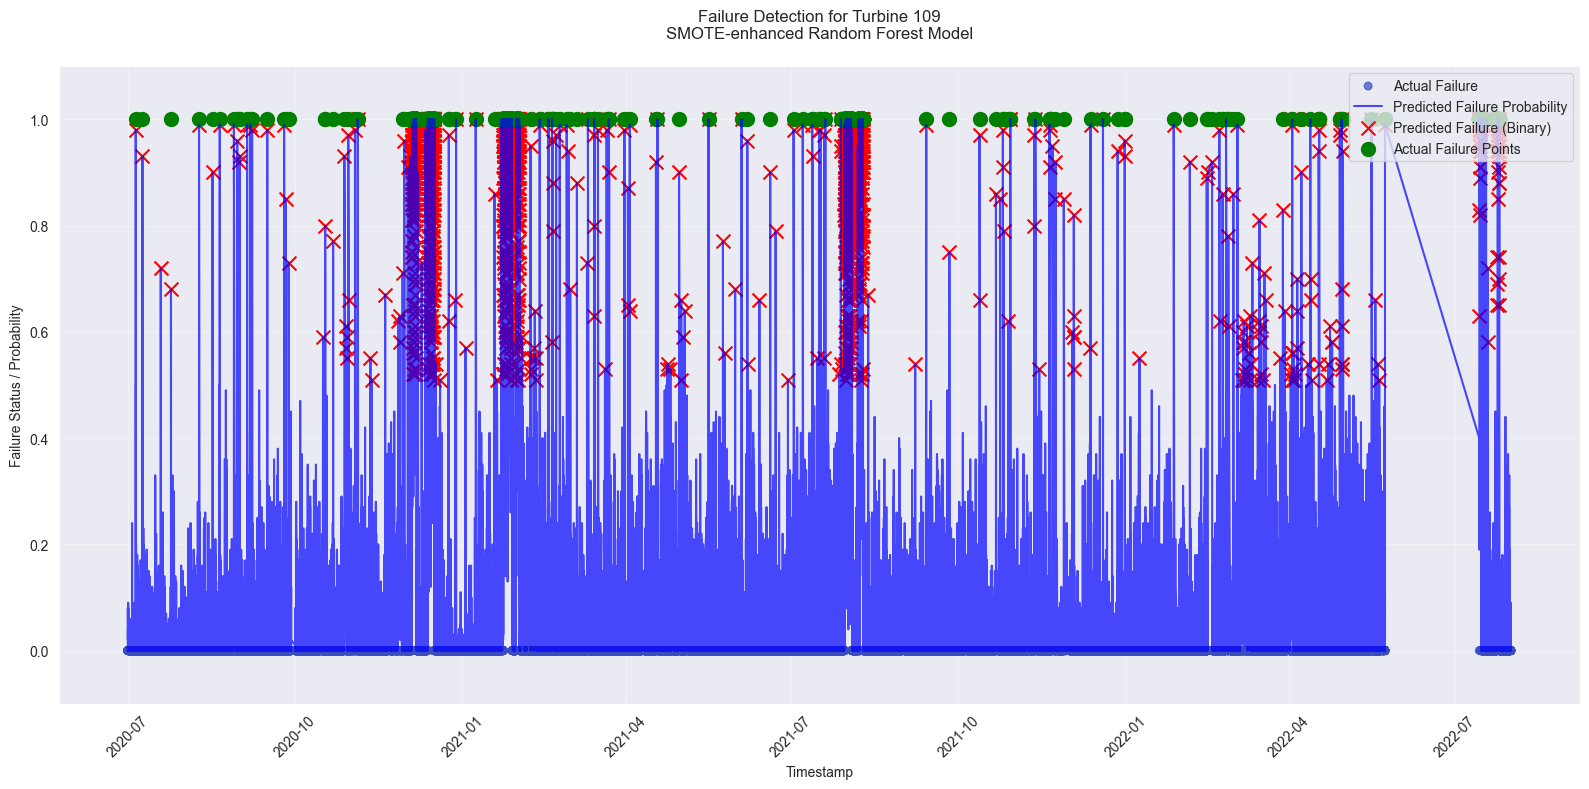


Performance Metrics for Turbine 109:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     89442
     Failure       0.95      0.91      0.93      2586

    accuracy                           1.00     92028
   macro avg       0.97      0.95      0.96     92028
weighted avg       1.00      1.00      1.00     92028



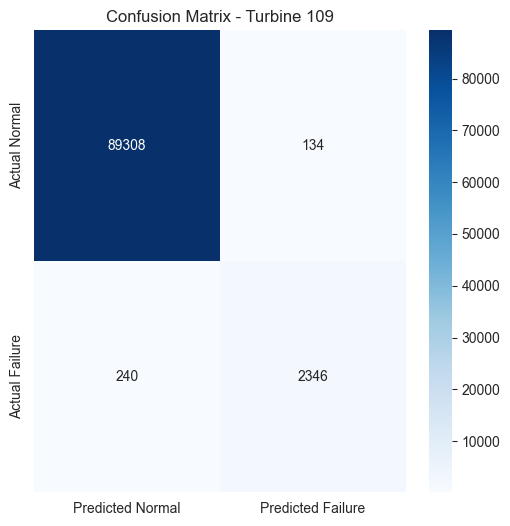

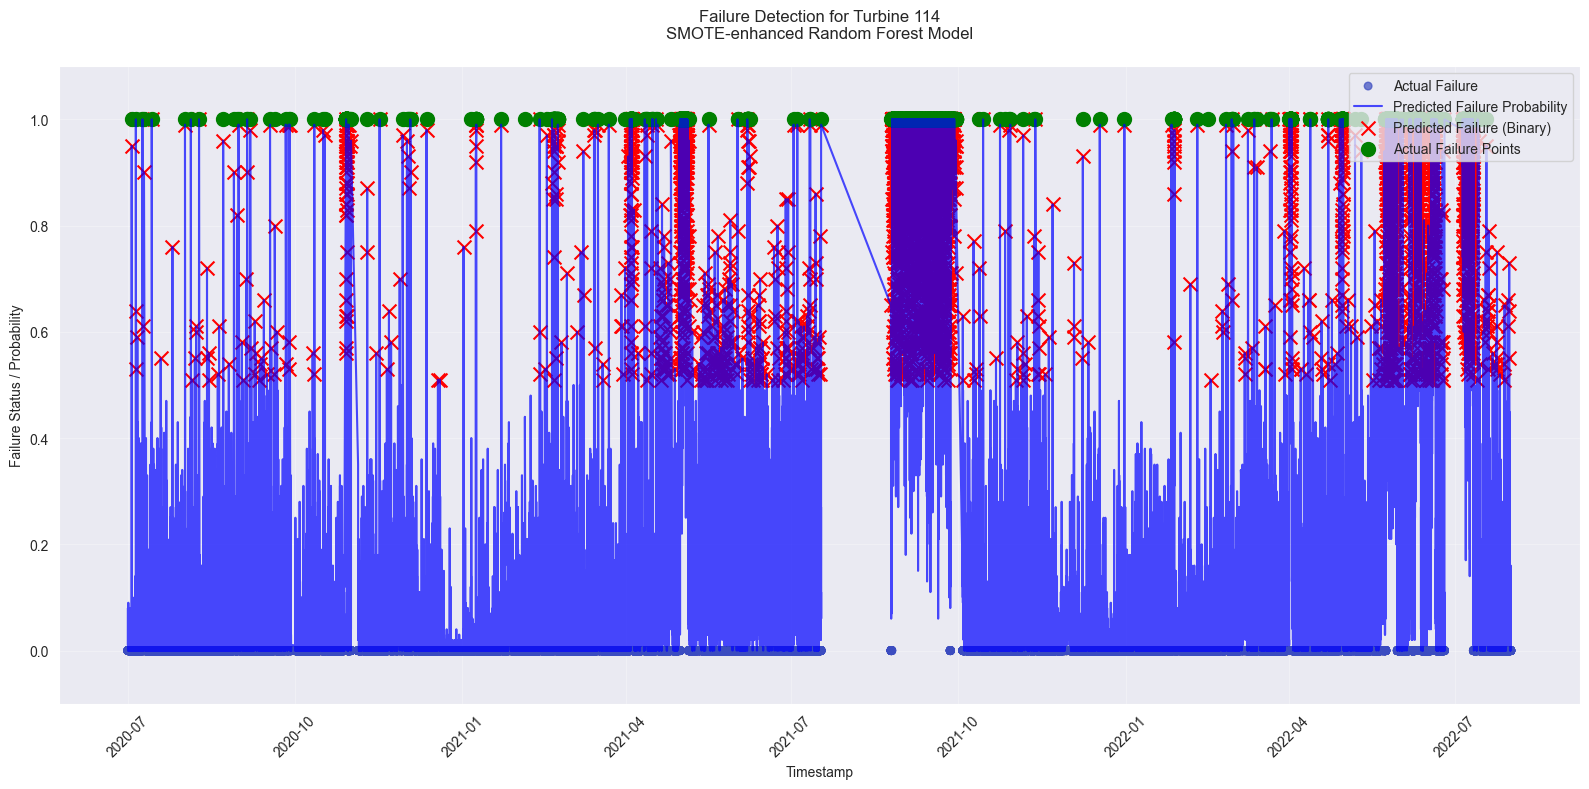


Performance Metrics for Turbine 114:
              precision    recall  f1-score   support

      Normal       1.00      0.99      0.99     83314
     Failure       0.94      0.95      0.95      8097

    accuracy                           0.99     91411
   macro avg       0.97      0.97      0.97     91411
weighted avg       0.99      0.99      0.99     91411



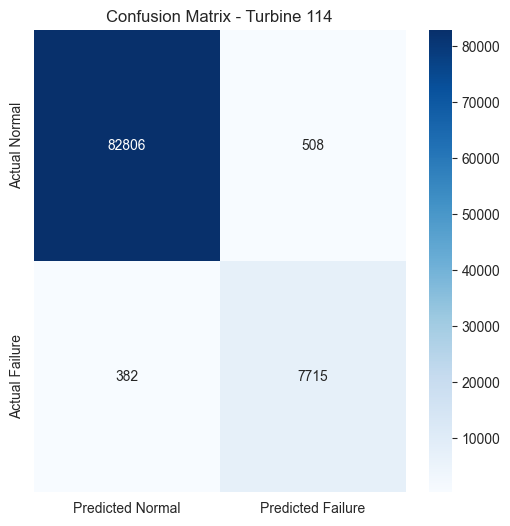

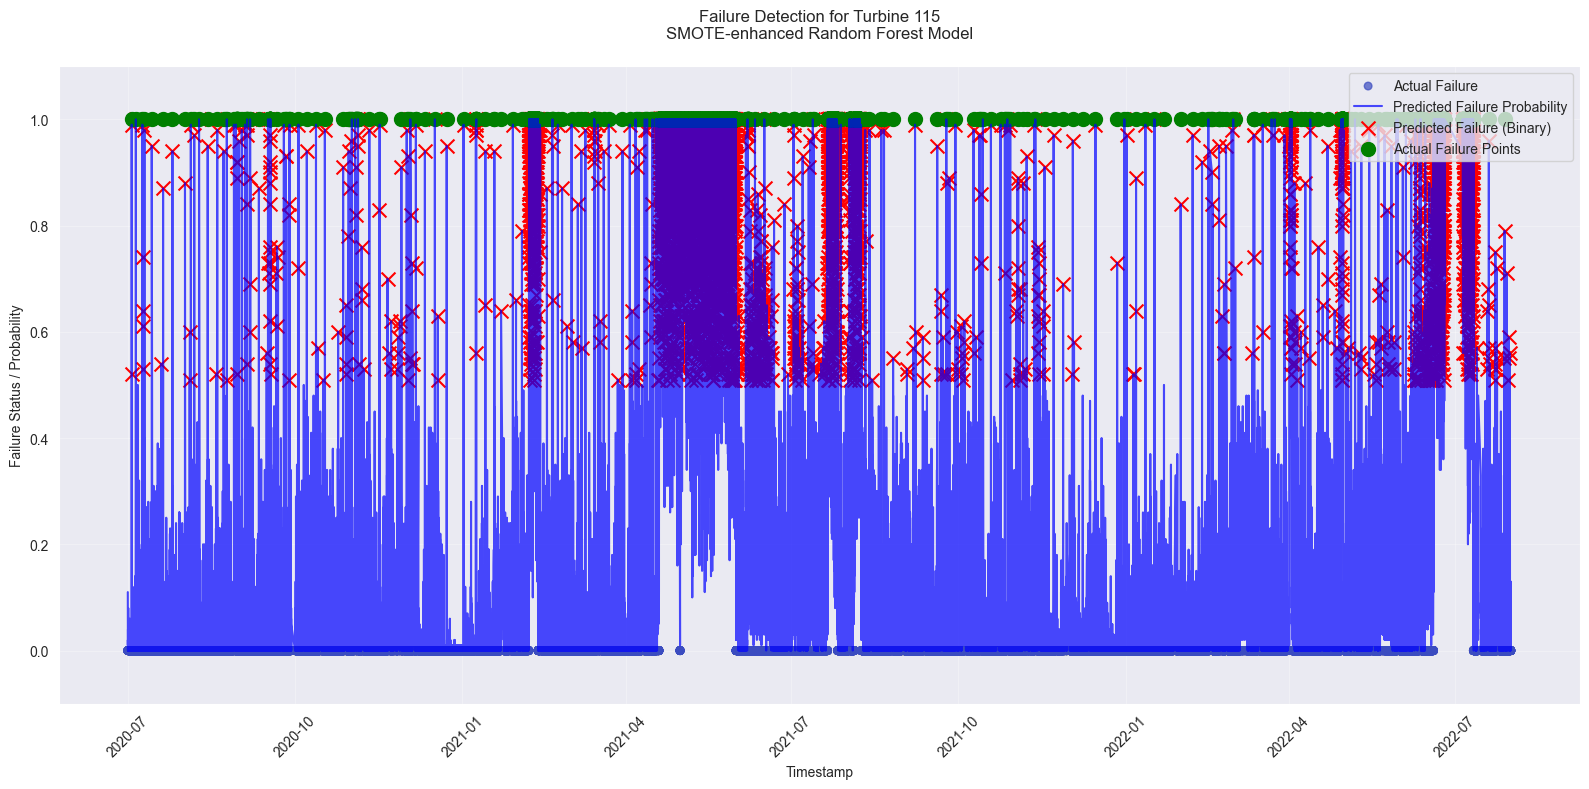


Performance Metrics for Turbine 115:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99     88615
     Failure       0.94      0.94      0.94      9691

    accuracy                           0.99     98306
   macro avg       0.97      0.97      0.97     98306
weighted avg       0.99      0.99      0.99     98306



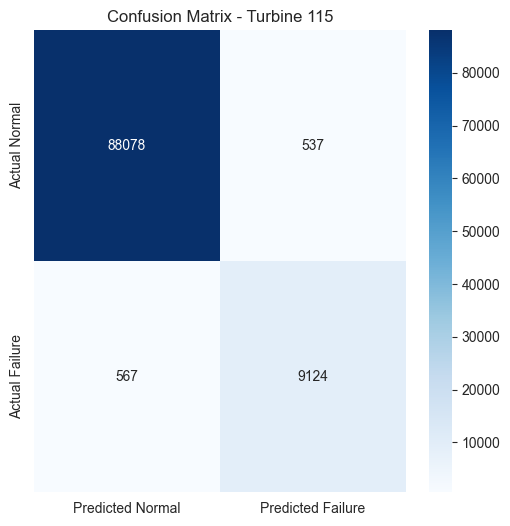

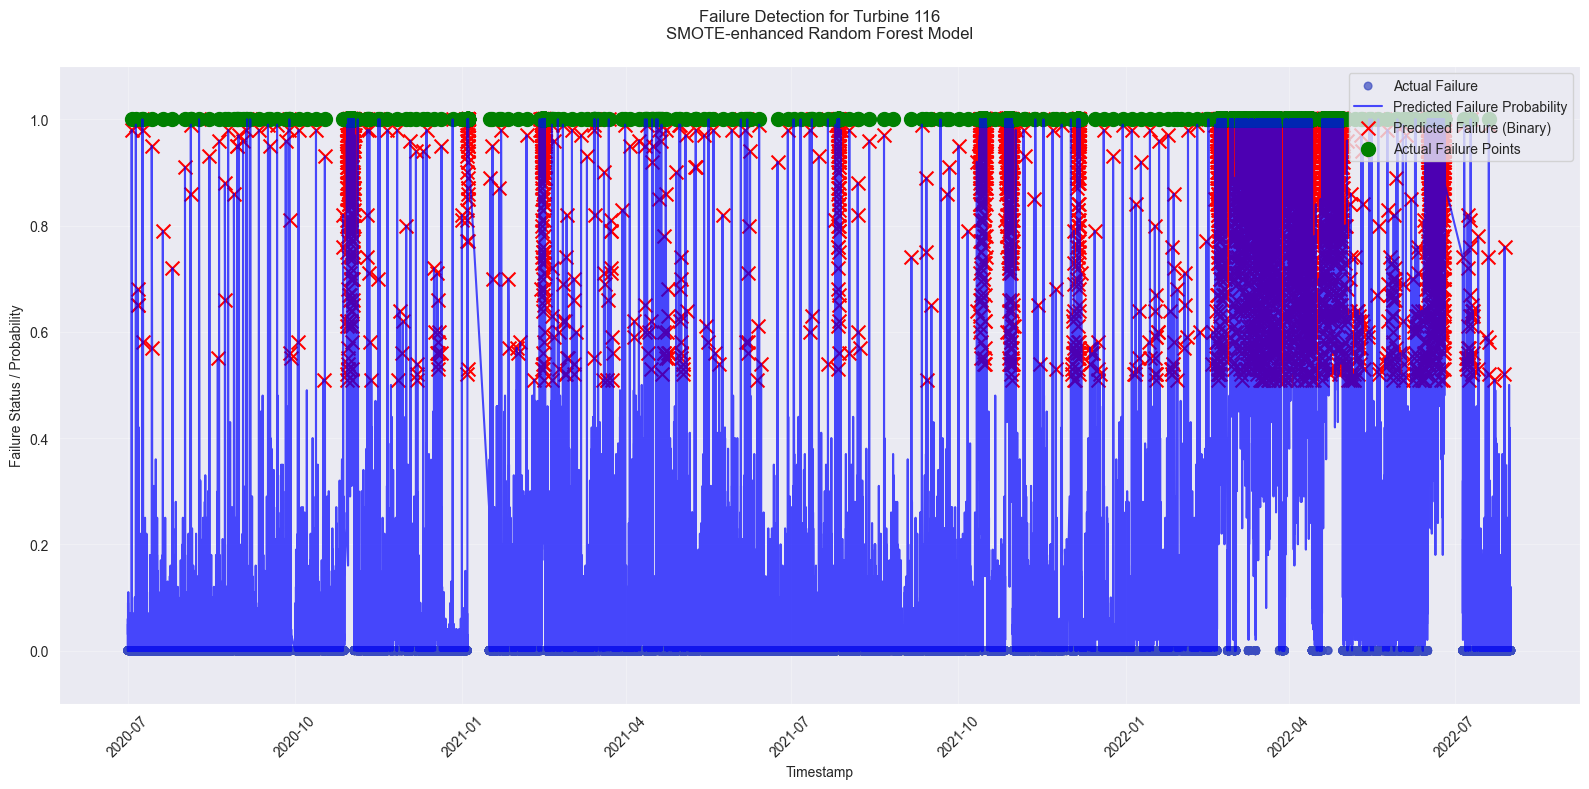


Performance Metrics for Turbine 116:
              precision    recall  f1-score   support

      Normal       0.99      0.99      0.99     85815
     Failure       0.96      0.95      0.96     10223

    accuracy                           0.99     96038
   macro avg       0.98      0.97      0.97     96038
weighted avg       0.99      0.99      0.99     96038



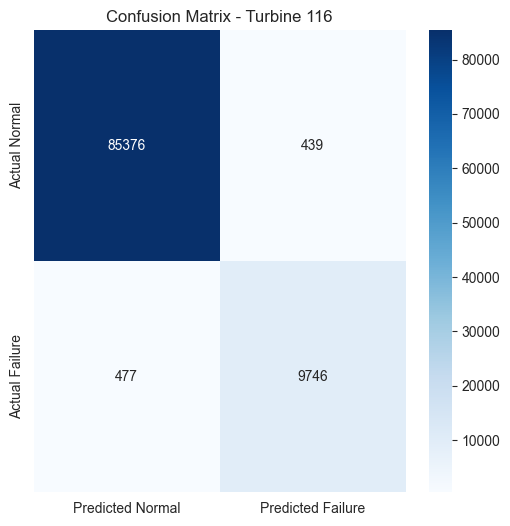

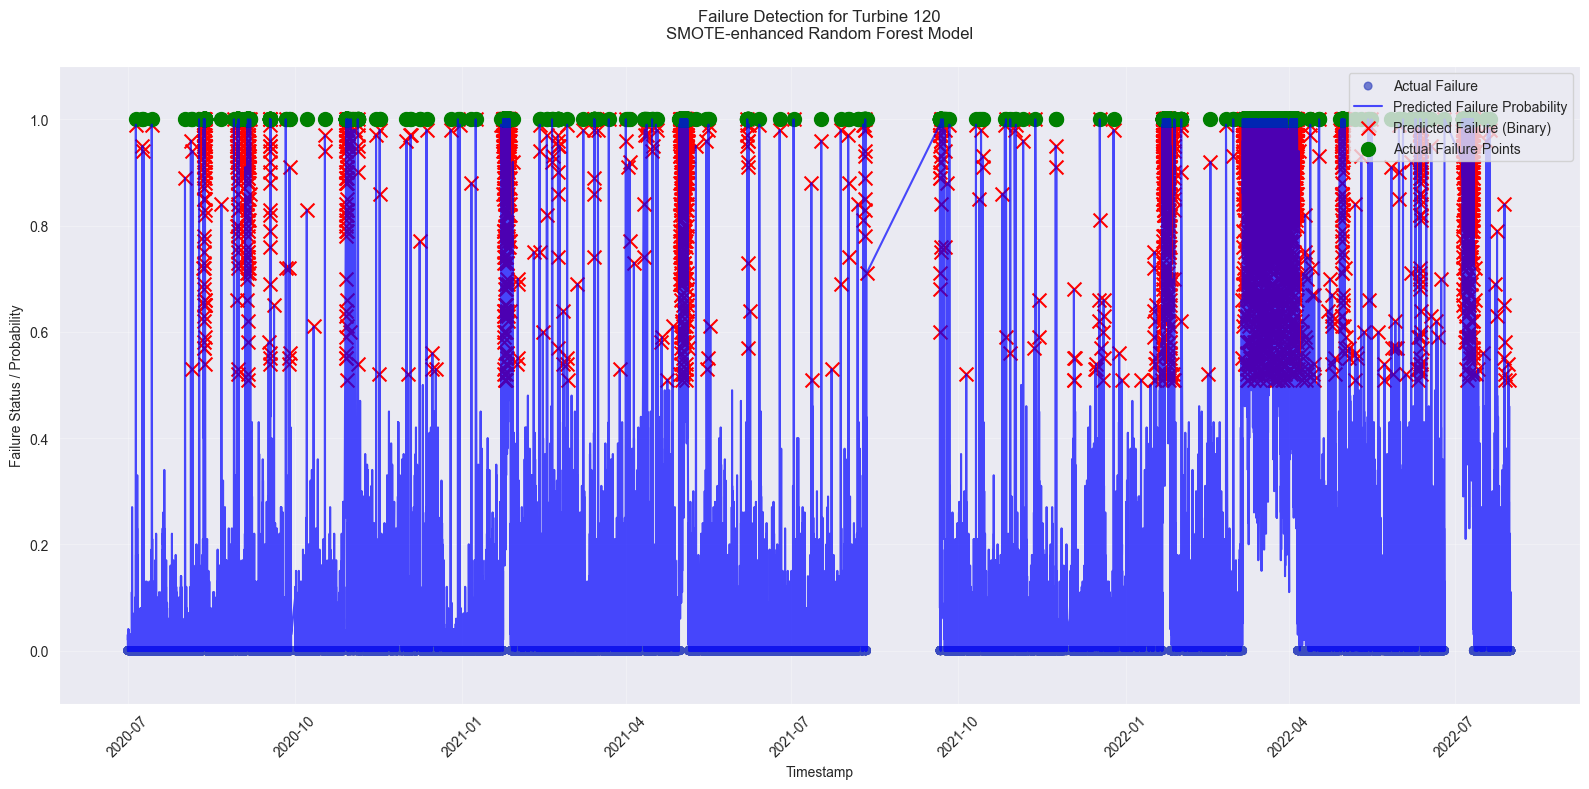


Performance Metrics for Turbine 120:
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00     85622
     Failure       0.97      0.94      0.96      7048

    accuracy                           0.99     92670
   macro avg       0.98      0.97      0.98     92670
weighted avg       0.99      0.99      0.99     92670



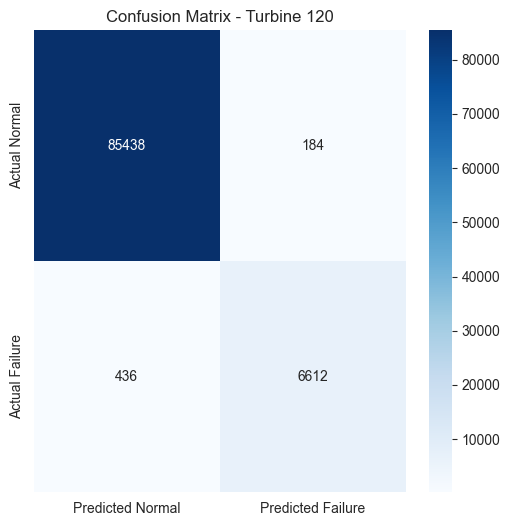

In [6]:
def plot_failure_comparison(turbine_id, data, model, features):
    # Filter data for the specific turbine
    turbine_data = data[data['plant_name'] == turbine_id].copy()

    if len(turbine_data) == 0:
        print(f"No data available for turbine {turbine_id}")
        return

    # Prepare features and get predictions
    X_turbine = turbine_data[features]
    turbine_data['predicted_failure'] = model.predict(X_turbine)
    turbine_data['predicted_prob'] = model.predict_proba(X_turbine)[:, 1]

    # Sort by timestamp
    turbine_data = turbine_data.sort_values('timestamp')

    # Create the plot
    plt.figure(figsize=(16, 8))

    # Plot actual failures
    plt.scatter(turbine_data['timestamp'], turbine_data['failure'],
                c=turbine_data['failure'], cmap='coolwarm',
                label='Actual Failure', alpha=0.7, s=30)

    # Plot predicted probabilities
    plt.plot(turbine_data['timestamp'], turbine_data['predicted_prob'],
             'b-', label='Predicted Failure Probability', alpha=0.7)

    # Plot predicted failures (using 0.5 as threshold)
    predicted_failures = turbine_data[turbine_data['predicted_failure'] == 1]
    plt.scatter(predicted_failures['timestamp'], predicted_failures['predicted_prob'],
                c='red', marker='x', s=100, label='Predicted Failure (Binary)')

    # Plot actual failures (as distinct points)
    actual_failures = turbine_data[turbine_data['failure'] == 1]
    plt.scatter(actual_failures['timestamp'], actual_failures['failure'],
                c='green', marker='o', s=100, label='Actual Failure Points')

    # Add details
    plt.title(f'Failure Detection for Turbine {turbine_id}\nSMOTE-enhanced Random Forest Model', pad=20)
    plt.xlabel('Timestamp')
    plt.ylabel('Failure Status / Probability')
    plt.ylim(-0.1, 1.1)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Calculate accuracy metrics for this turbine
    y_true = turbine_data['failure']
    y_pred = turbine_data['predicted_failure']
    y_prob = turbine_data['predicted_prob']

    print(f"\nPerformance Metrics for Turbine {turbine_id}:")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Failure']))

    # Plot confusion matrix for this turbine
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Normal', 'Predicted Failure'],
                yticklabels=['Actual Normal', 'Actual Failure'])
    plt.title(f'Confusion Matrix - Turbine {turbine_id}')
    plt.show()

# Get unique turbine IDs
turbine_ids = data_cleaned['plant_name'].unique()

# Plot for each turbine (first 5 for demonstration)
for turbine_id in turbine_ids[:5]:
    plot_failure_comparison(turbine_id, data_cleaned, rf_classifier, selected_features)

## Plot actual vs predicted failures over time for each turbine (without SMOTE)

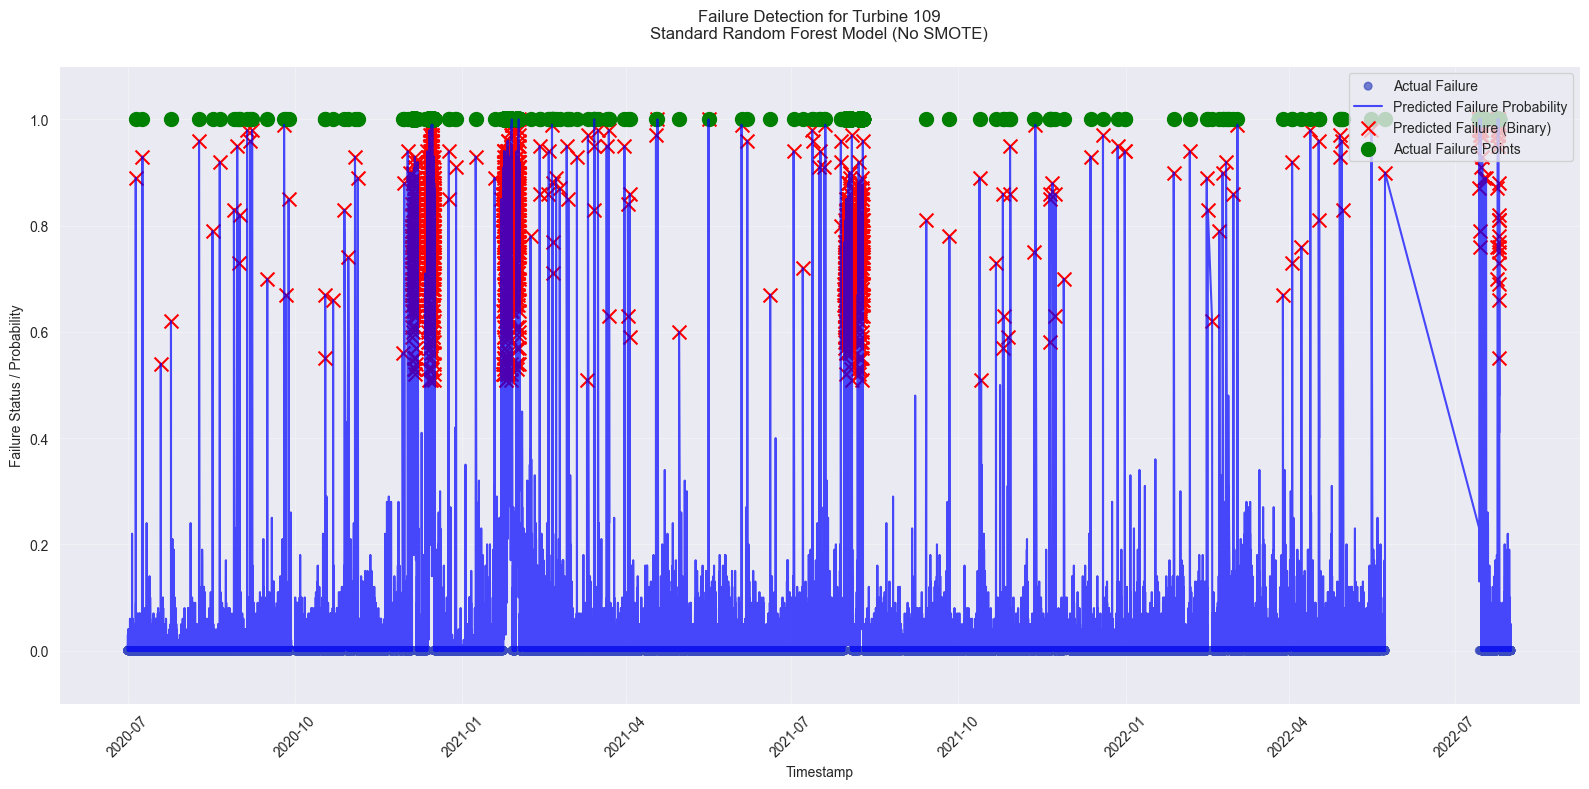


Performance Metrics for Turbine 109:
              precision    recall  f1-score   support

      Normal       0.99      1.00      1.00     89442
     Failure       0.99      0.80      0.89      2586

    accuracy                           0.99     92028
   macro avg       0.99      0.90      0.94     92028
weighted avg       0.99      0.99      0.99     92028



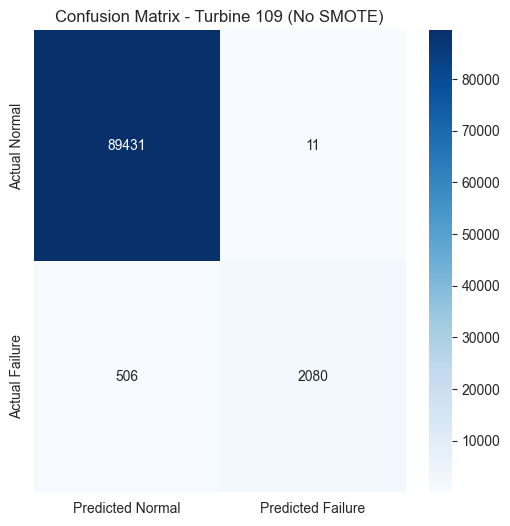

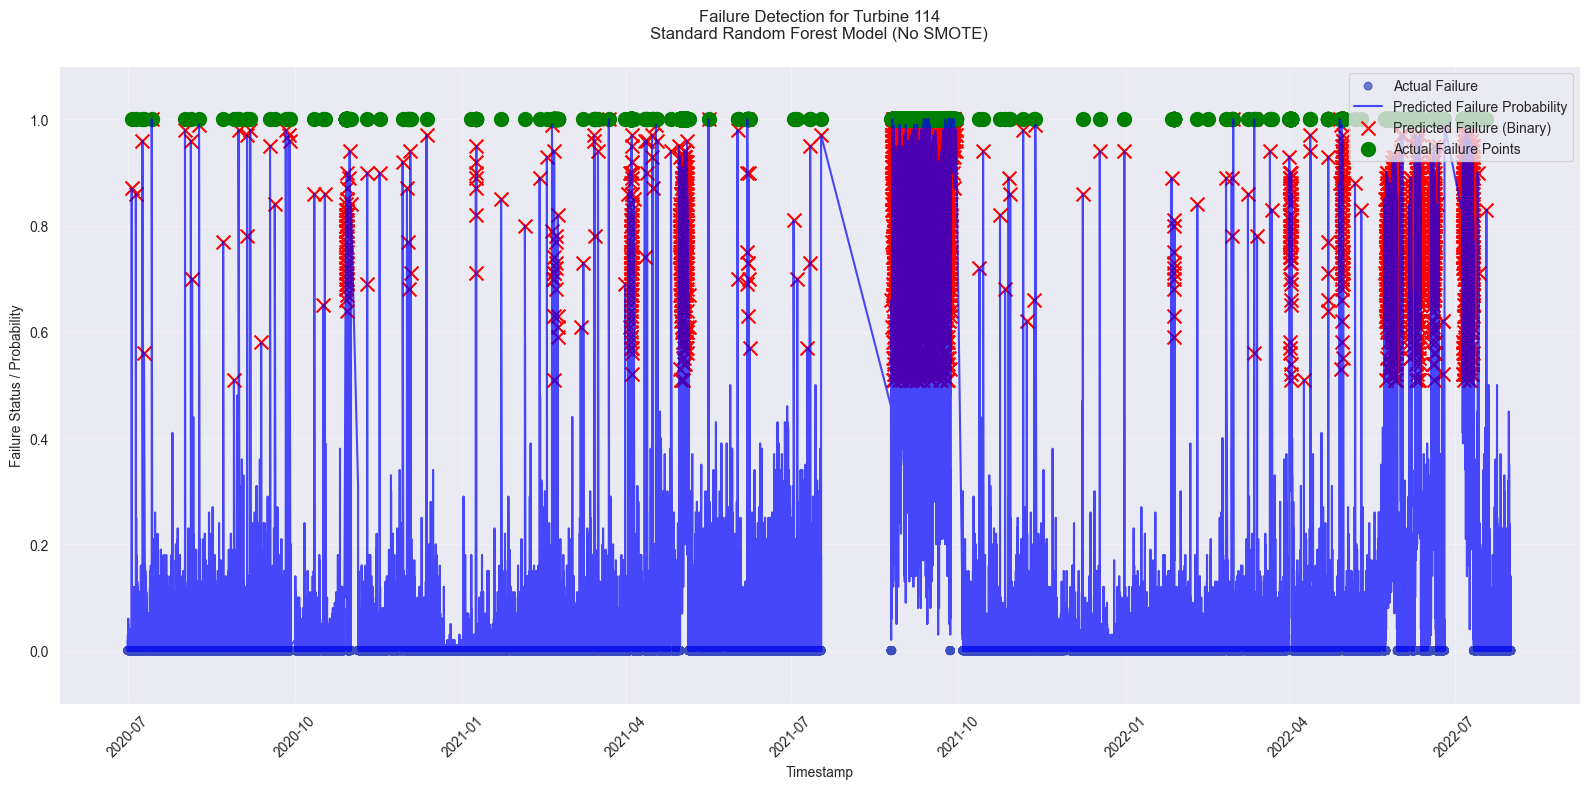


Performance Metrics for Turbine 114:
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99     83314
     Failure       1.00      0.83      0.90      8097

    accuracy                           0.98     91411
   macro avg       0.99      0.91      0.95     91411
weighted avg       0.98      0.98      0.98     91411



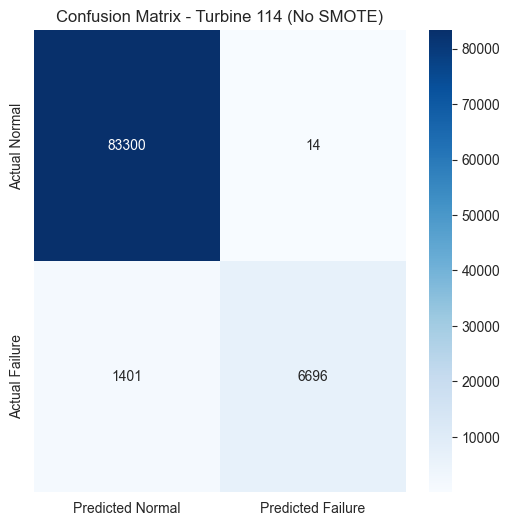

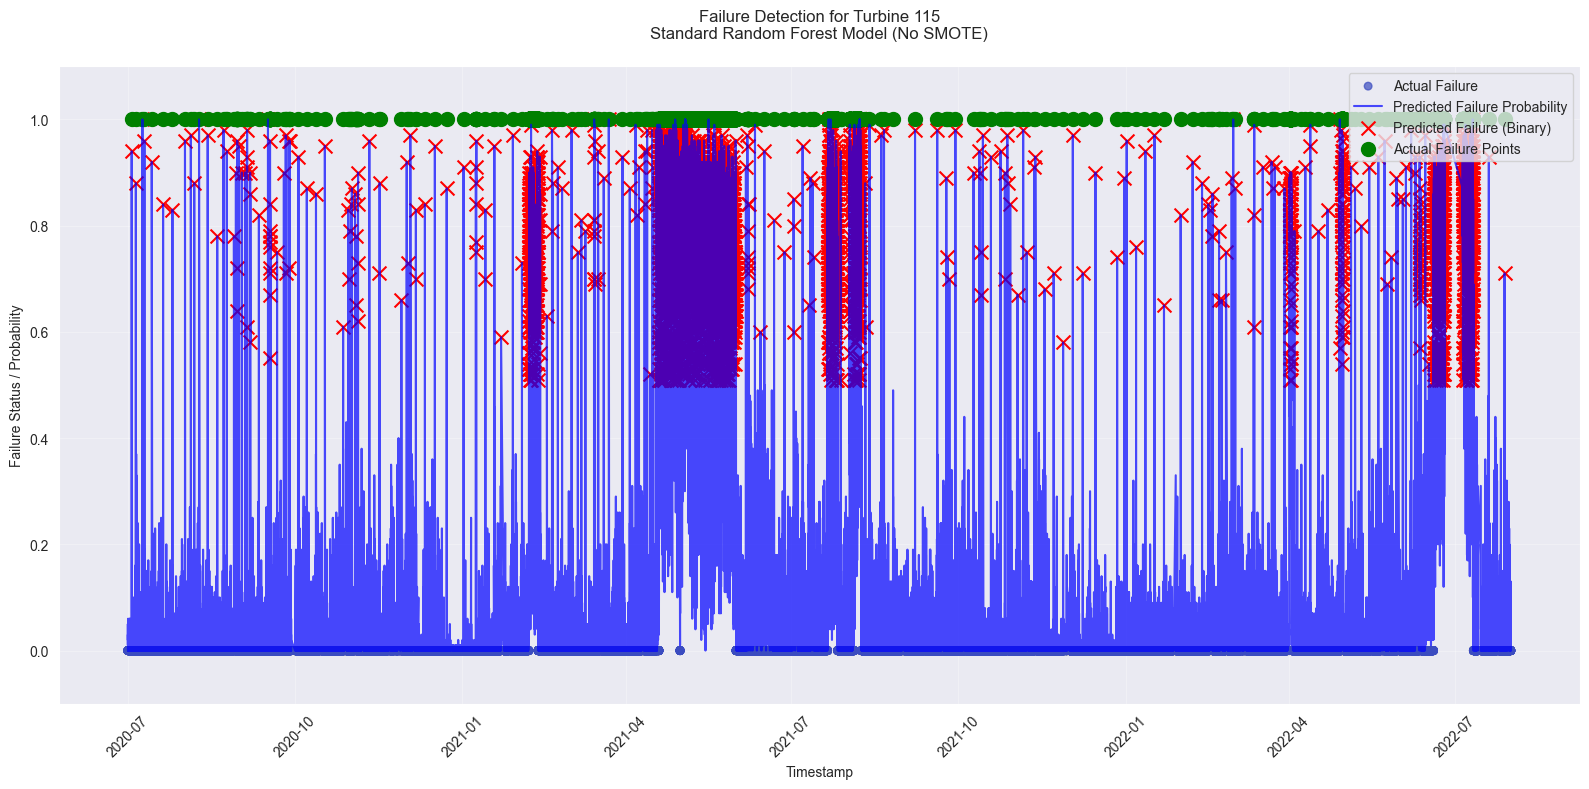


Performance Metrics for Turbine 115:
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99     88615
     Failure       1.00      0.83      0.90      9691

    accuracy                           0.98     98306
   macro avg       0.99      0.91      0.95     98306
weighted avg       0.98      0.98      0.98     98306



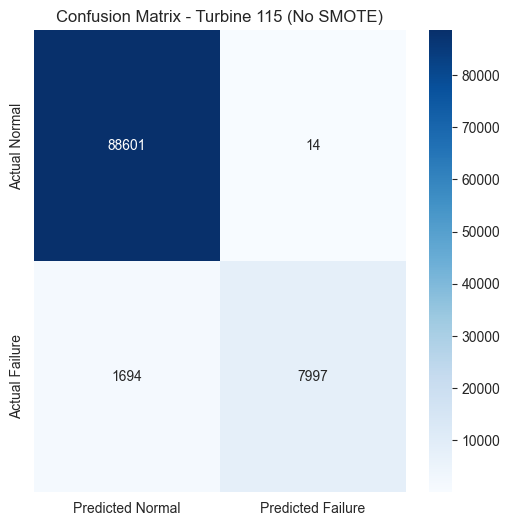

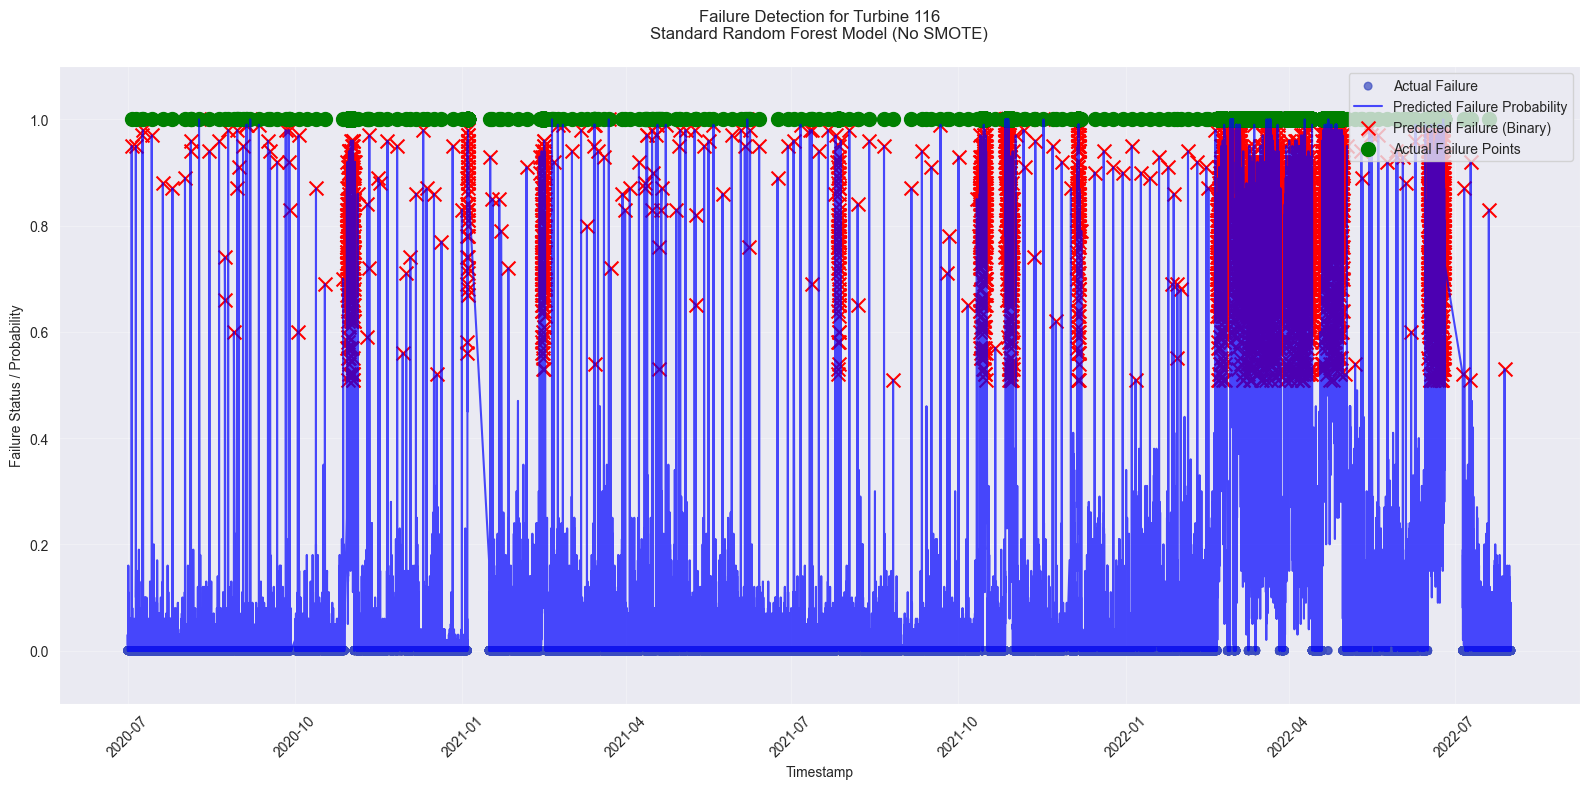


Performance Metrics for Turbine 116:
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99     85815
     Failure       1.00      0.85      0.92     10223

    accuracy                           0.98     96038
   macro avg       0.99      0.93      0.95     96038
weighted avg       0.98      0.98      0.98     96038



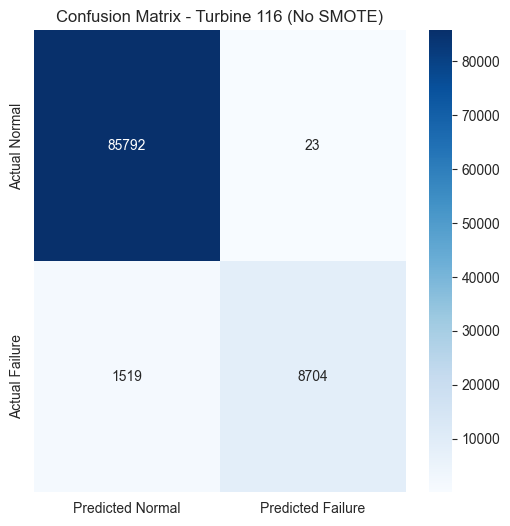

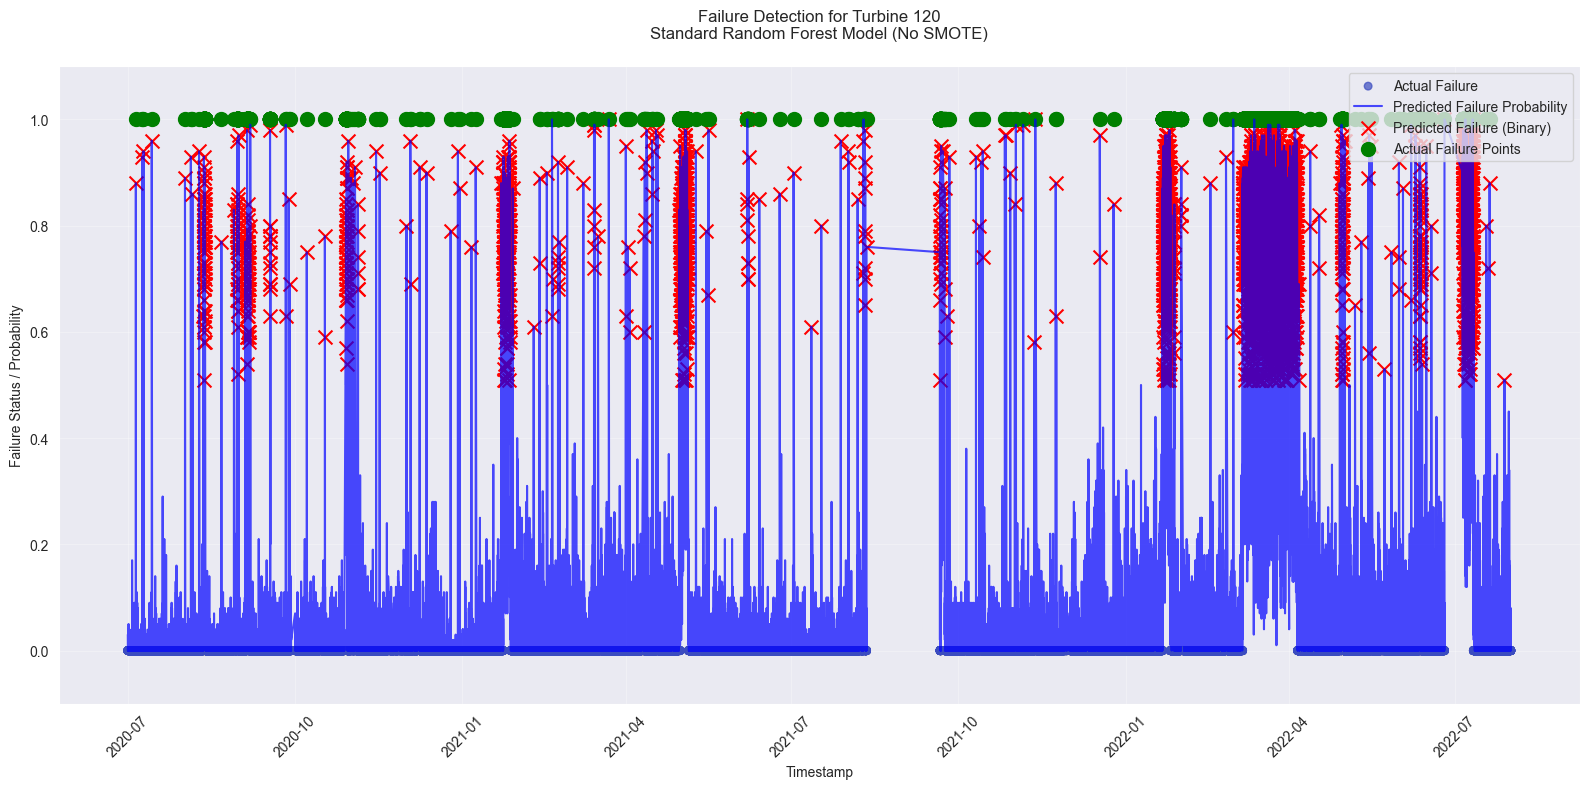


Performance Metrics for Turbine 120:
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99     85622
     Failure       1.00      0.82      0.90      7048

    accuracy                           0.99     92670
   macro avg       0.99      0.91      0.95     92670
weighted avg       0.99      0.99      0.99     92670



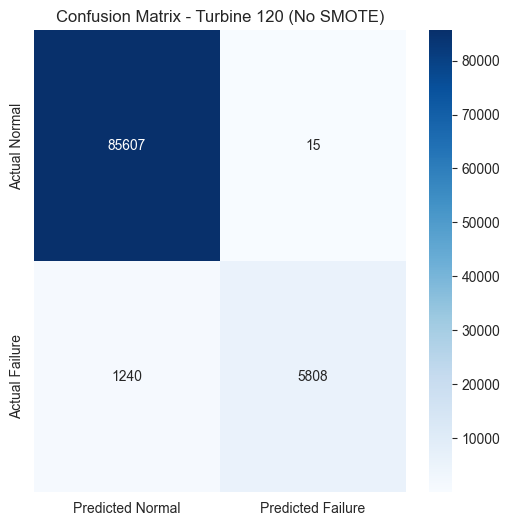

In [7]:
def plot_failure_comparison_nosmote(turbine_id, data, model, features):
    # Filter data for the specific turbine
    turbine_data = data[data['plant_name'] == turbine_id].copy()

    if len(turbine_data) == 0:
        print(f"No data available for turbine {turbine_id}")
        return

    # Prepare features and get predictions
    X_turbine = turbine_data[features]
    turbine_data['predicted_failure'] = model.predict(X_turbine)
    turbine_data['predicted_prob'] = model.predict_proba(X_turbine)[:, 1]

    # Sort by timestamp
    turbine_data = turbine_data.sort_values('timestamp')

    # Create the plot
    plt.figure(figsize=(16, 8))

    # Plot actual failures
    plt.scatter(turbine_data['timestamp'], turbine_data['failure'],
                c=turbine_data['failure'], cmap='coolwarm',
                label='Actual Failure', alpha=0.7, s=30)

    # Plot predicted probabilities
    plt.plot(turbine_data['timestamp'], turbine_data['predicted_prob'],
             'b-', label='Predicted Failure Probability', alpha=0.7)

    # Plot predicted failures (using 0.5 as threshold)
    predicted_failures = turbine_data[turbine_data['predicted_failure'] == 1]
    plt.scatter(predicted_failures['timestamp'], predicted_failures['predicted_prob'],
                c='red', marker='x', s=100, label='Predicted Failure (Binary)')

    # Plot actual failures (as distinct points)
    actual_failures = turbine_data[turbine_data['failure'] == 1]
    plt.scatter(actual_failures['timestamp'], actual_failures['failure'],
                c='green', marker='o', s=100, label='Actual Failure Points')

    # Add details
    plt.title(f'Failure Detection for Turbine {turbine_id}\nStandard Random Forest Model (No SMOTE)', pad=20)
    plt.xlabel('Timestamp')
    plt.ylabel('Failure Status / Probability')
    plt.ylim(-0.1, 1.1)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    # Rotate x-axis labels for better readability
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Calculate accuracy metrics for this turbine
    y_true = turbine_data['failure']
    y_pred = turbine_data['predicted_failure']
    y_prob = turbine_data['predicted_prob']

    print(f"\nPerformance Metrics for Turbine {turbine_id}:")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Failure']))

    # Plot confusion matrix for this turbine
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted Normal', 'Predicted Failure'],
                yticklabels=['Actual Normal', 'Actual Failure'])
    plt.title(f'Confusion Matrix - Turbine {turbine_id} (No SMOTE)')
    plt.show()

# Train a classifier without SMOTE
rf_classifier_nosmote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier_nosmote.fit(X_train_class, y_train_class)

# Get unique turbine IDs
turbine_ids = data_cleaned['plant_name'].unique()

# Plot for each turbine (first 5 for demonstration)
for turbine_id in turbine_ids[:5]:
    plot_failure_comparison_nosmote(turbine_id, data_cleaned, rf_classifier_nosmote, selected_features)

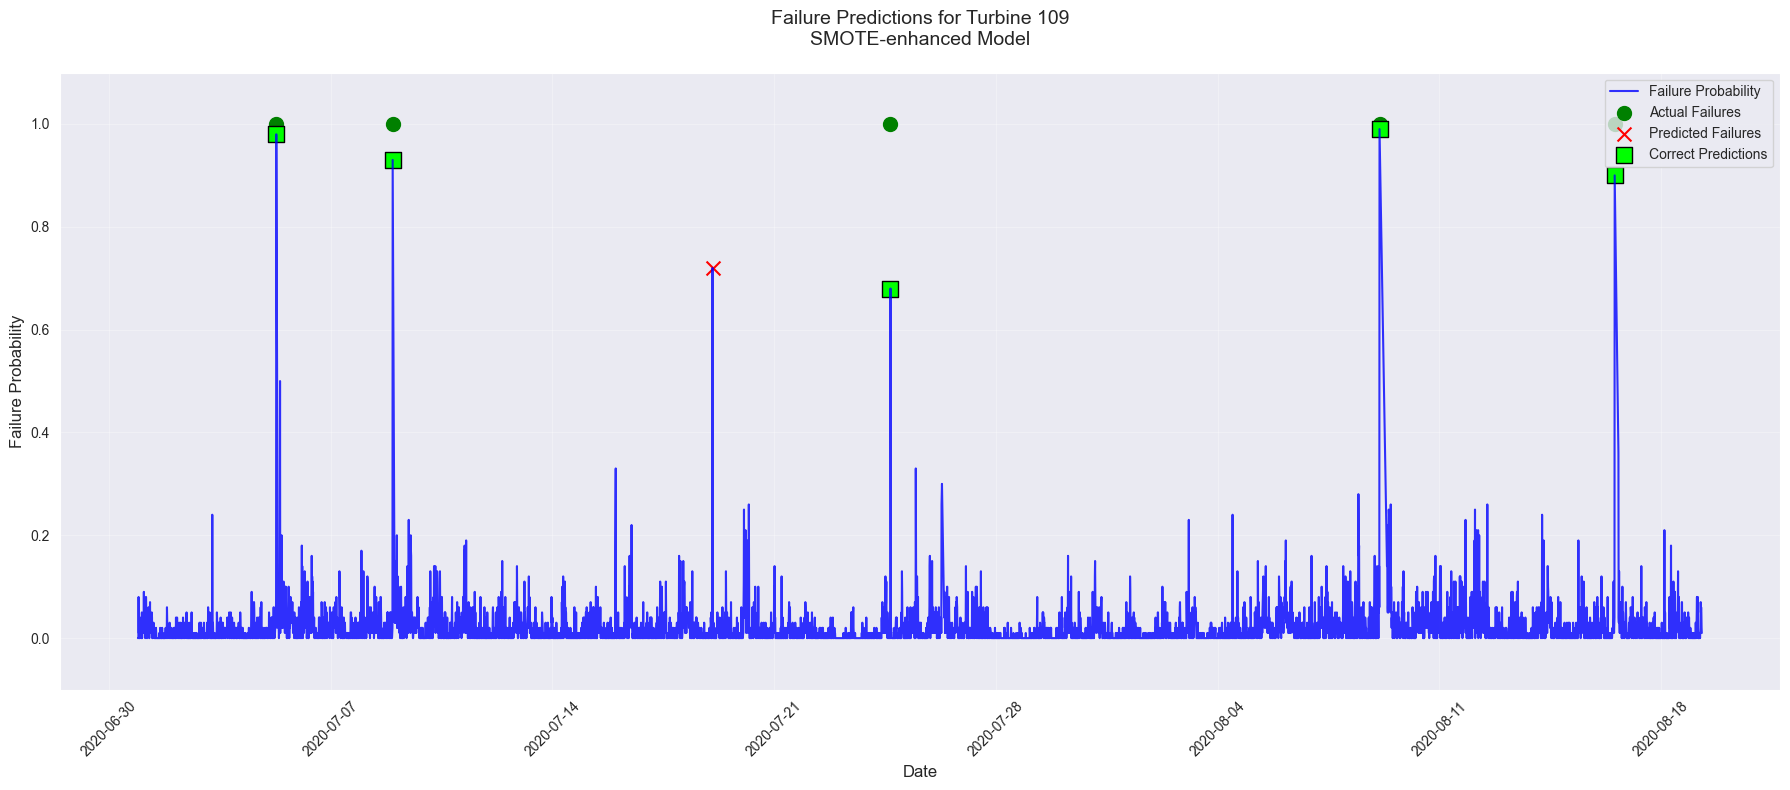


Metrics for Turbine 109 (SMOTE-enhanced Model):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      7001
     Failure       0.83      1.00      0.91         5

    accuracy                           1.00      7006
   macro avg       0.92      1.00      0.95      7006
weighted avg       1.00      1.00      1.00      7006



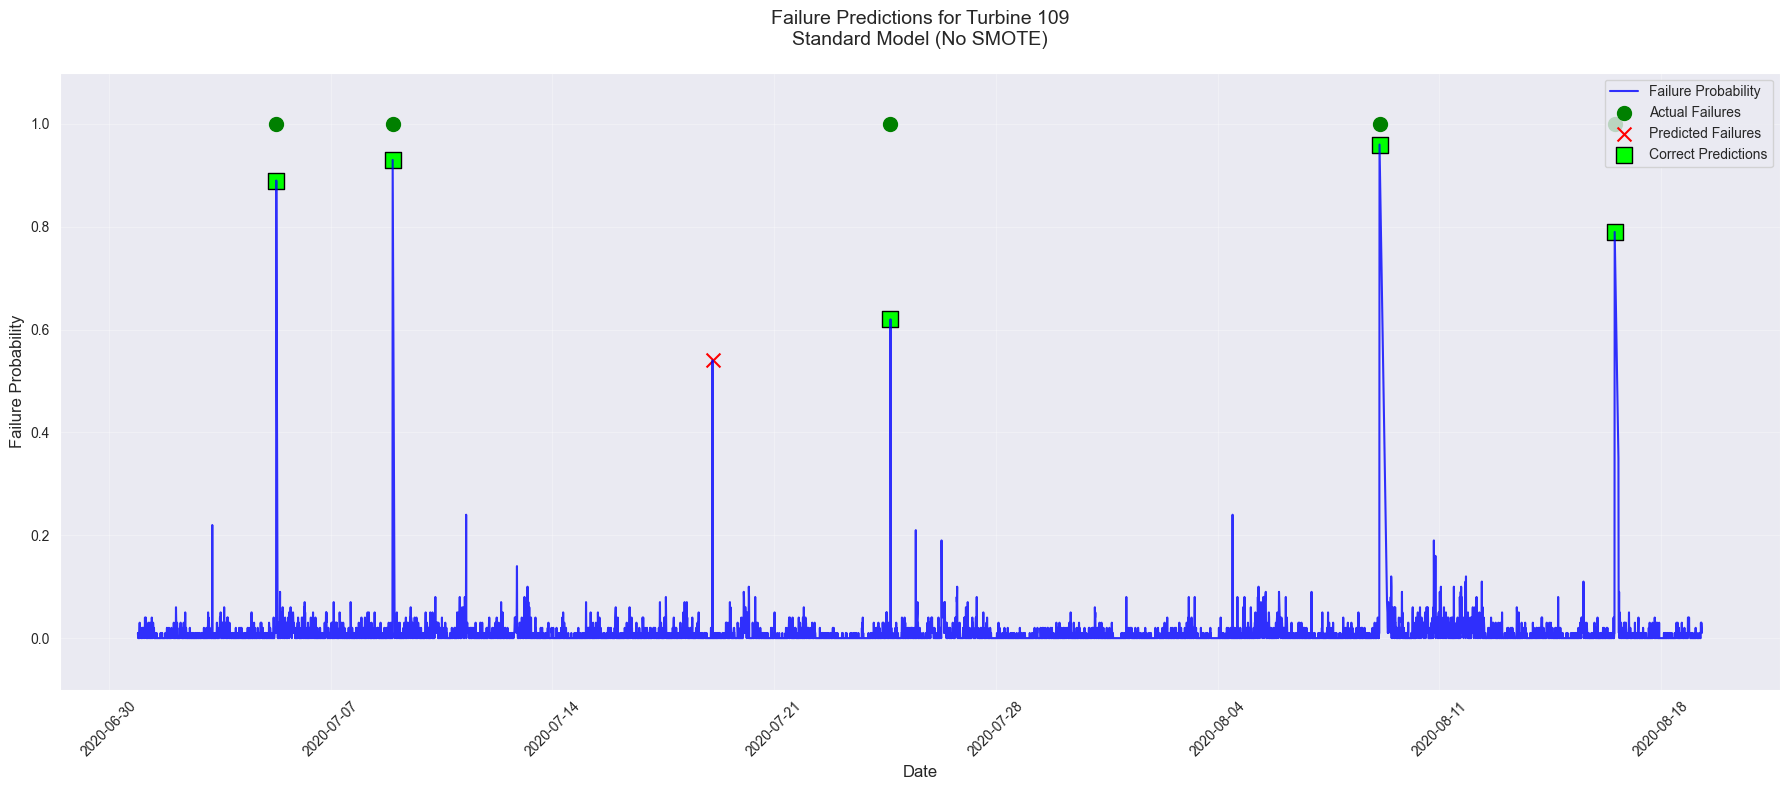


Metrics for Turbine 109 (Standard Model (No SMOTE)):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      7001
     Failure       0.83      1.00      0.91         5

    accuracy                           1.00      7006
   macro avg       0.92      1.00      0.95      7006
weighted avg       1.00      1.00      1.00      7006



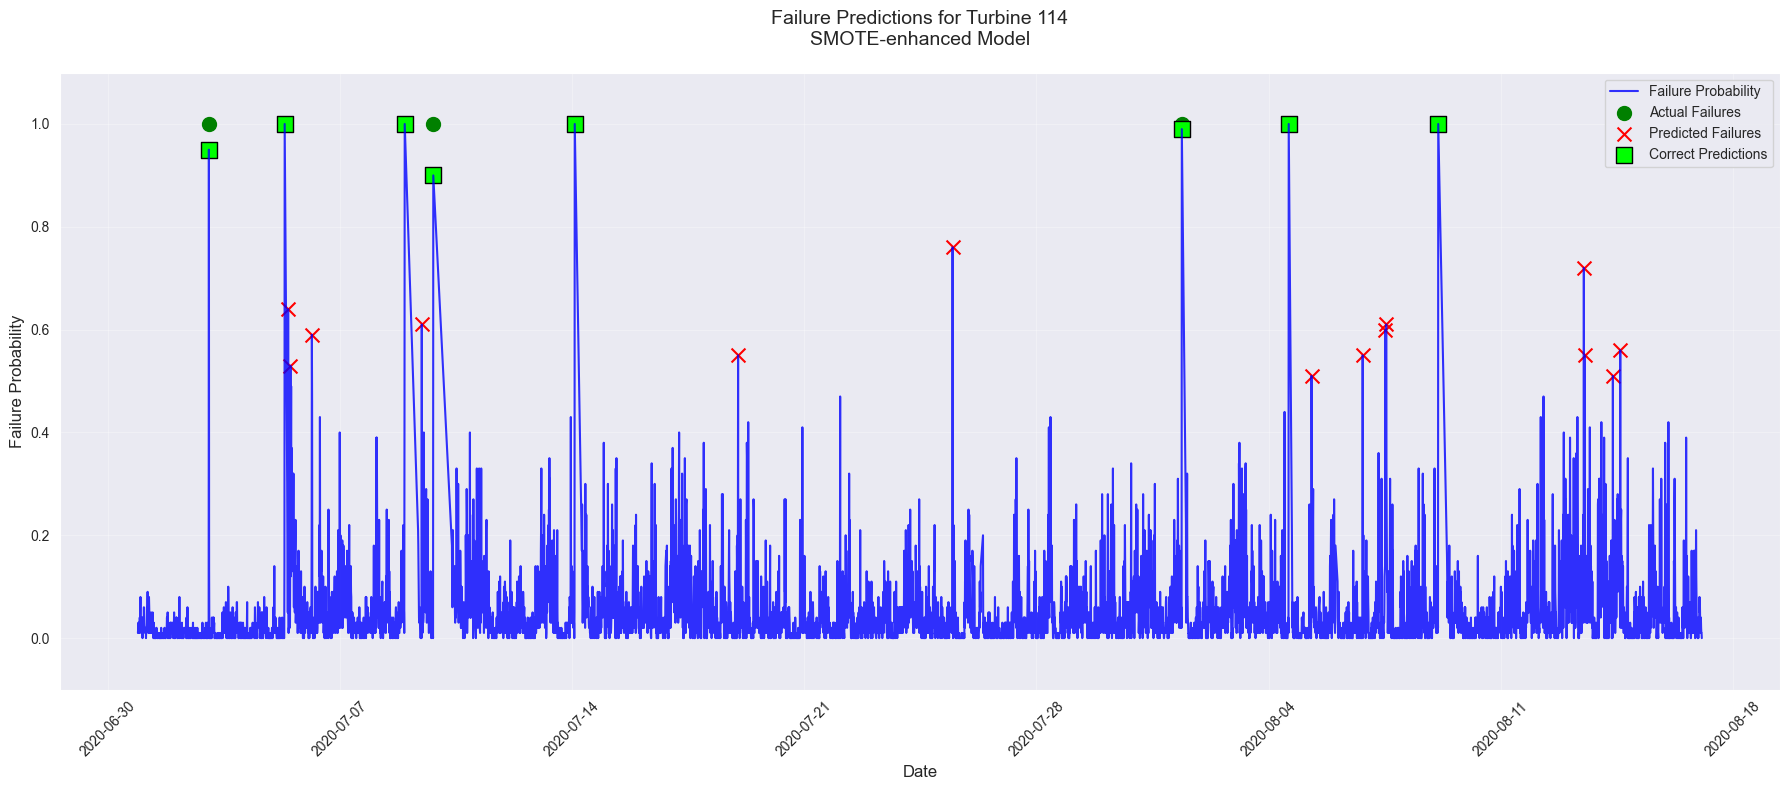


Metrics for Turbine 114 (SMOTE-enhanced Model):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      6499
     Failure       0.36      1.00      0.53         8

    accuracy                           1.00      6507
   macro avg       0.68      1.00      0.77      6507
weighted avg       1.00      1.00      1.00      6507



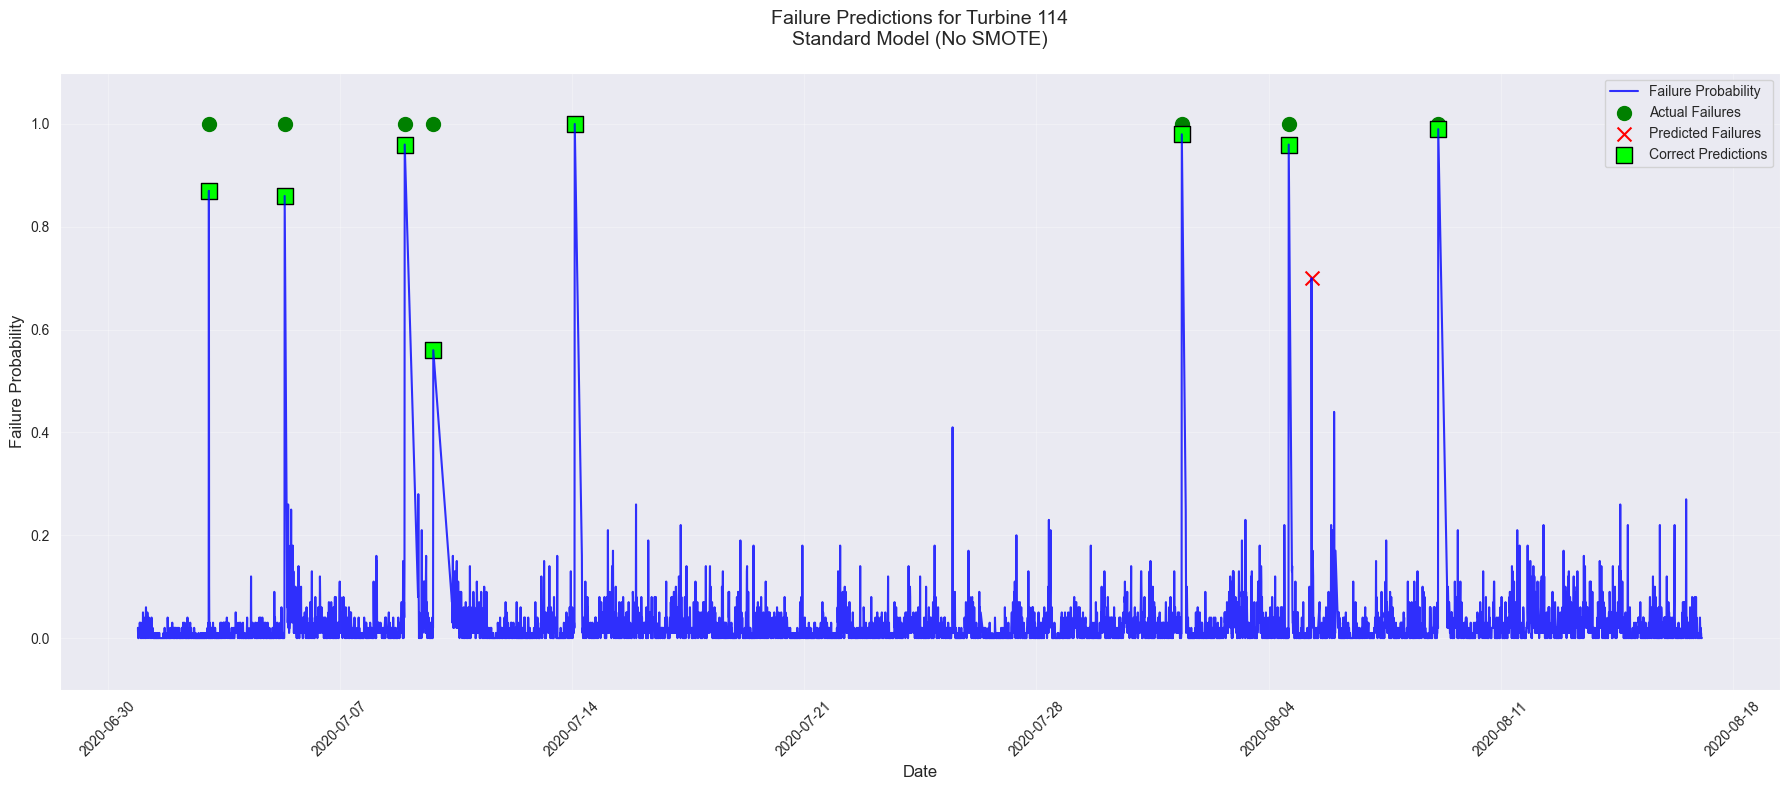


Metrics for Turbine 114 (Standard Model (No SMOTE)):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      6499
     Failure       0.89      1.00      0.94         8

    accuracy                           1.00      6507
   macro avg       0.94      1.00      0.97      6507
weighted avg       1.00      1.00      1.00      6507



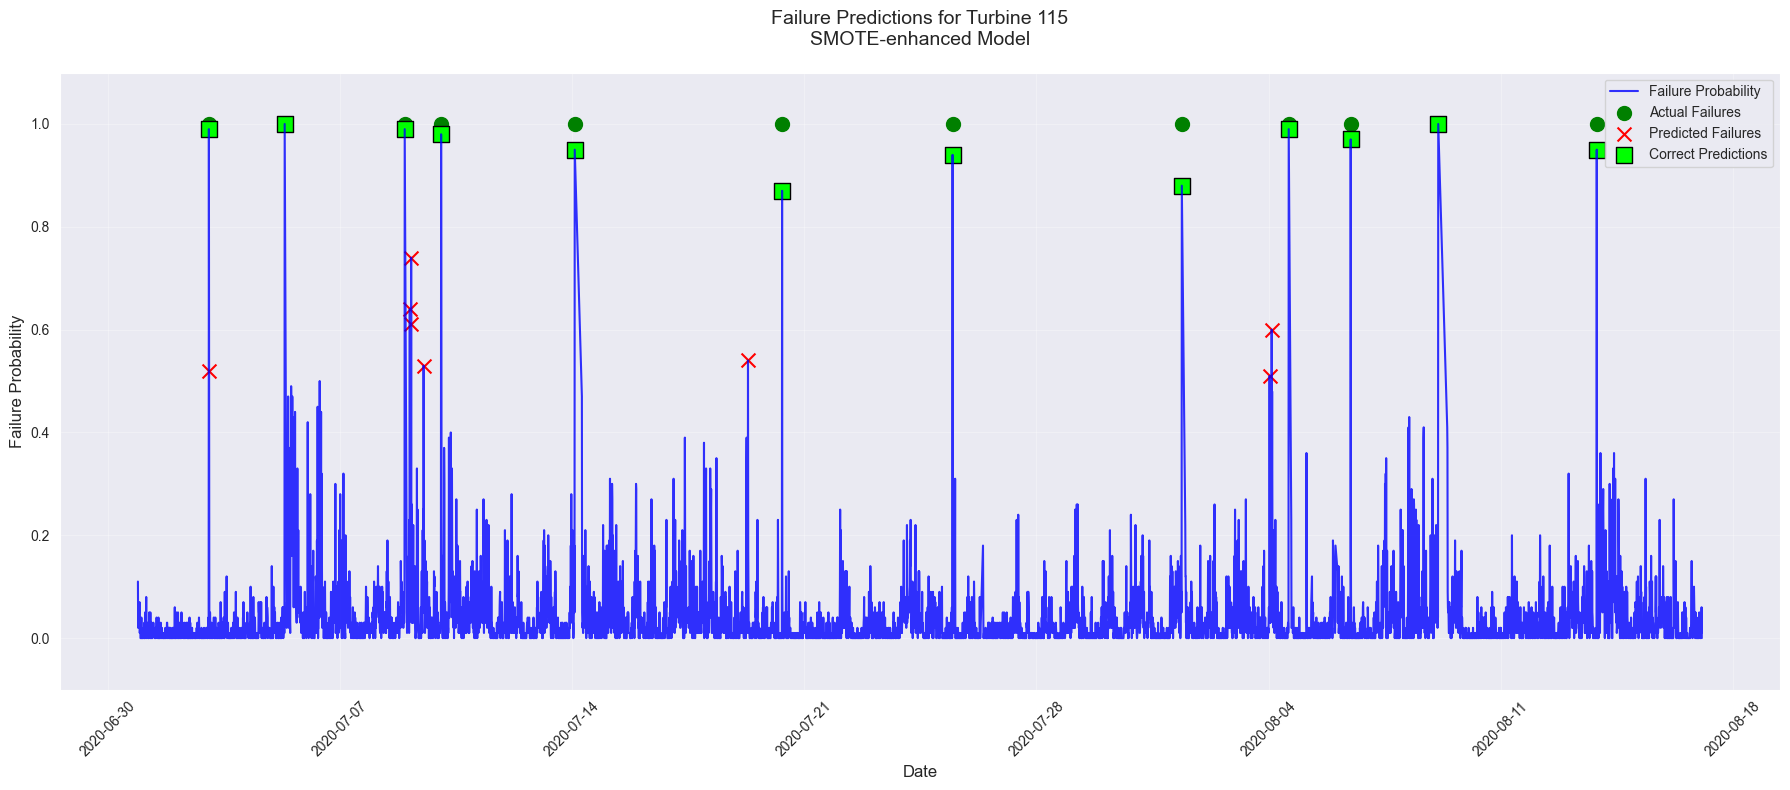


Metrics for Turbine 115 (SMOTE-enhanced Model):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      6627
     Failure       0.60      1.00      0.75        12

    accuracy                           1.00      6639
   macro avg       0.80      1.00      0.87      6639
weighted avg       1.00      1.00      1.00      6639



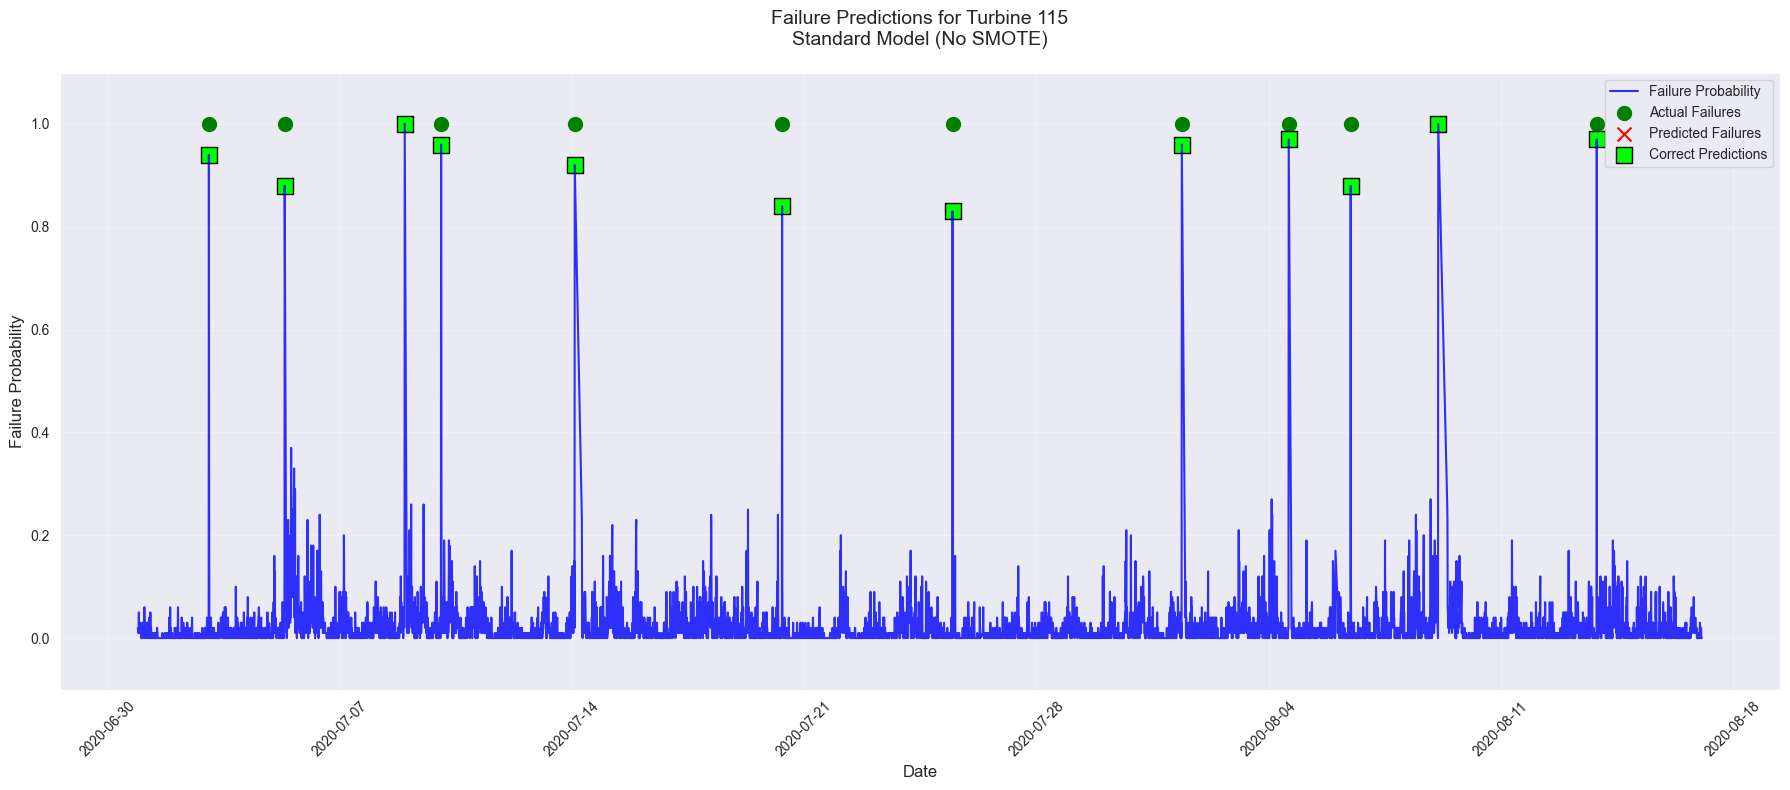


Metrics for Turbine 115 (Standard Model (No SMOTE)):
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      6627
     Failure       1.00      1.00      1.00        12

    accuracy                           1.00      6639
   macro avg       1.00      1.00      1.00      6639
weighted avg       1.00      1.00      1.00      6639



In [8]:
def plot_two_month_comparison(turbine_id, data, model, features, start_date, title_suffix=""):
    """
    Plot 2 months of failure predictions for a specific turbine
    """
    # Filter data for the specific turbine and time period
    turbine_data = data[(data['plant_name'] == turbine_id) &
                       (data['timestamp'] >= start_date) &
                       (data['timestamp'] <= start_date + pd.Timedelta(days=60))].copy()

    if len(turbine_data) == 0:
        print(f"No data available for turbine {turbine_id} in this period")
        return

    # Get predictions
    X_turbine = turbine_data[features]
    turbine_data['predicted_failure'] = model.predict(X_turbine)
    turbine_data['predicted_prob'] = model.predict_proba(X_turbine)[:, 1]
    turbine_data = turbine_data.sort_values('timestamp')

    # Create plot
    plt.figure(figsize=(18, 8))

    # Plot predicted probability curve
    plt.plot(turbine_data['timestamp'], turbine_data['predicted_prob'],
             'b-', label='Failure Probability', alpha=0.8, linewidth=1.5)

    # Plot actual failures
    actual_failures = turbine_data[turbine_data['failure'] == 1]
    plt.scatter(actual_failures['timestamp'], actual_failures['failure'],
                c='green', marker='o', s=100, label='Actual Failures')

    # Plot predicted failures (threshold at 0.5)
    predicted_failures = turbine_data[turbine_data['predicted_failure'] == 1]
    plt.scatter(predicted_failures['timestamp'], predicted_failures['predicted_prob'],
                c='red', marker='x', s=100, label='Predicted Failures')

    # Highlight correct predictions
    correct_predictions = turbine_data[(turbine_data['failure'] == 1) &
                                      (turbine_data['predicted_failure'] == 1)]
    plt.scatter(correct_predictions['timestamp'], correct_predictions['predicted_prob'],
                c='lime', marker='s', s=120, label='Correct Predictions', edgecolor='black')

    # Formatting
    plt.title(f'Failure Predictions for Turbine {turbine_id}\n{title_suffix}', pad=20, fontsize=14)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Failure Probability', fontsize=12)
    plt.ylim(-0.1, 1.1)
    plt.legend(loc='upper right', fontsize=10)
    plt.grid(True, alpha=0.3)

    # Format x-axis
    plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    # Print metrics for this period
    y_true = turbine_data['failure']
    y_pred = turbine_data['predicted_failure']
    print(f"\nMetrics for Turbine {turbine_id} ({title_suffix}):")
    print(classification_report(y_true, y_pred, target_names=['Normal', 'Failure']))

# Find a suitable 2-month period containing failures
def find_failure_period(data, turbine_id):
    turbine_data = data[data['plant_name'] == turbine_id]
    failures = turbine_data[turbine_data['failure'] == 1]
    if len(failures) > 0:
        return failures['timestamp'].iloc[0] - pd.Timedelta(days=15)  # Start 15 days before first failure
    return turbine_data['timestamp'].iloc[0]  # Default to first date if no failures

# Plot for first 3 turbines - with and without SMOTE
import matplotlib.dates as mdates

for turbine_id in turbine_ids[:3]:
    # Find a suitable 2-month period for this turbine
    start_date = find_failure_period(data_cleaned, turbine_id)

    # Plot with SMOTE
    plot_two_month_comparison(turbine_id, data_cleaned, rf_classifier, selected_features,
                            start_date, "SMOTE-enhanced Model")

    # Plot without SMOTE
    plot_two_month_comparison(turbine_id, data_cleaned, rf_classifier_nosmote, selected_features,
                            start_date, "Standard Model (No SMOTE)")